## This mini-project will focus on processing and replacing missing values in a dataset. 
- The dataset chosen or generated must have a sufficient number of missing values to contribute to the main objective of this project.
- Each part in the project must be accompanied by a clear, valid, and detailed explanation, along with the corresponding code blocks.
- Respect exactly the same number of cells. Your marks will be strongly infuenced by the respect of this structure.

In [1]:
import pandas as pd
import numpy as np
#I chose the melbourne-housing-snapshots dataset because it contains interesting features, with #numerical and categorical values and also it contains missing values in columns Car, #Landsize,BuildingArea,YearBuilt,councilArea which is required for this mini-project.

file_path = '/kaggle/input/melbourne-housing-snapshot/melb_data.csv'
data = pd.read_csv(file_path)
# Display the major informations about the dataset
print("Dataset Overview:")
print(data.info())

# Get the columns containing missing values and their number in order to make sure this dataset is great for the assignment
missing_values = data.isnull().sum()
print("\nNumber of missing values in each column:")
print(missing_values)

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  f

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split





#I chose the melbourne-housing-snapshots dataset because it contains interesting features, with #numerical and categorical values and also it contains missing values in columns Car, #Landsize,BuildingArea,YearBuilt,councilArea which is required for this mini-project.
# We start off by loading our dataset
file_path = '/kaggle/input/melbourne-housing-snapshot/melb_data.csv'
data = pd.read_csv(file_path)
# Display the major informations about the dataset
print("Dataset Overview:")
print(data.info())


# Get the columns containing missing values and their number in order to make sure this dataset is great for the assignment
missing_values = data.isnull().sum()
print("\nNumber of missing values in each column:")
print(missing_values)

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  f

# 2. Clean your data: 
- Evaluate the quality of data.
- Identify relevant features.
- Missing values or any additional operations ? (use different missing appraoches to tackle the missing values issue, create different data variants for a later comparison).   
- statistics, check data types, conversions and more ?
- Divide data into two parts one for experiments, another portion for validation (explain the logic of your splitting).

Data Types:
Suburb            object
Address           object
Rooms              int64
Type              object
Price            float64
Method            object
SellerG           object
Date              object
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea       object
Lattitude        float64
Longtitude       float64
Regionname        object
Propertycount    float64
dtype: object

Descriptive Statistics for Numerical Features:
              Rooms         Price      Distance      Postcode      Bedroom2  \
count  13580.000000  1.358000e+04  13580.000000  13580.000000  13580.000000   
mean       2.937997  1.075684e+06     10.137776   3105.301915      2.914728   
std        0.955748  6.393107e+05      5.868725     90.676964      0.965921   
min        1.000000  8.500000e+04      0.000000   3000.000000      0.000000   
25%   

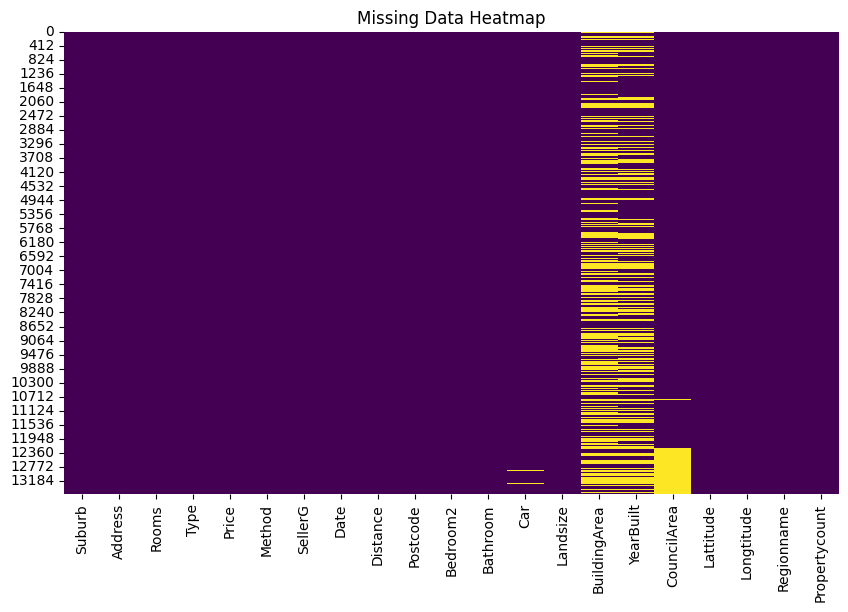


Missing Values After Handling:
Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                 0
Landsize            0
BuildingArea        0
YearBuilt        5344
CouncilArea         0
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64

Experiment Data Shape: (10814, 21)
Validation Data Shape: (2704, 21)

Descriptive Statistics for Experiment Data:
              Rooms         Price      Distance      Postcode      Bedroom2  \
count  10814.000000  1.081400e+04  10814.000000  10814.000000  10814.000000   
mean       2.932125  1.072061e+06     10.136786   3105.002867      2.910579   
std        0.954635  6.394849e+05      5.834134     89.975155      0.966972   
min        1.000000  8.500000e+04      0.000000   3000.000000 

In [3]:
# 1. Evaluate the quality of data
# Check data types and basic statistics
print("Data Types:")
print(data.dtypes)

print("\nDescriptive Statistics for Numerical Features:")
print(data.describe())

# 2. Identify relevant features
# Check unique values in categorical features to understand their distribution and detect anomalies
categorical_features = data.select_dtypes(include=['object']).columns
print("\nUnique values in categorical features:")
for col in categorical_features:
    print(f"{col}: {data[col].nunique()} unique values")

# 3. Missing values and additional operations
# Visualize missing values as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

# Handle missing values with different approaches:
# - Drop rows with missing values for 'Car'
# - Mean imputation for 'BuildingArea'
# - Predictive imputation for 'YearBuilt'
# - Mode imputation for 'CouncilArea'

# 3.1 Drop rows with missing values for 'Car'
data_drop = data.dropna(subset=['Car'])

# 3.2 Mean imputation for 'BuildingArea'
data_mean = data_drop.copy()
data_mean['BuildingArea'] = data_mean['BuildingArea'].fillna(data_mean['BuildingArea'].mean())

# 3.3 Predictive Imputation for 'YearBuilt'
# You can use regression for predictive imputation, this will be done in the following steps

# 3.4 Mode imputation for 'CouncilArea'
data_final = data_mean.copy()
data_final['CouncilArea'] = data_final['CouncilArea'].fillna(data_final['CouncilArea'].mode()[0])

# Verify missing values have been handled
print("\nMissing Values After Handling:")
print(data_final.isnull().sum())

# 4. Divide data into two parts: one for experiments (training) and another for validation
# The logic of splitting: Typically, 80% of the data is used for training, and 20% is reserved for validation
experiment_data, validation_data = train_test_split(data_final, test_size=0.2, random_state=42)

print("\nExperiment Data Shape:", experiment_data.shape)
print("Validation Data Shape:", validation_data.shape)

# Output descriptive statistics for the experiment and validation datasets
print("\nDescriptive Statistics for Experiment Data:")
print(experiment_data.describe())

print("\nDescriptive Statistics for Validation Data:")
print(validation_data.describe())


# 3. Exploratory Data Analyses
- Describe the methodology you will follow to achieve your objectives, relatioships analysis ? feature engineering ? 
- Apply your appraoch, and cite your findings.
- Draft a conclusion, and define new operations.
- Use visaluzation to understand your findings.


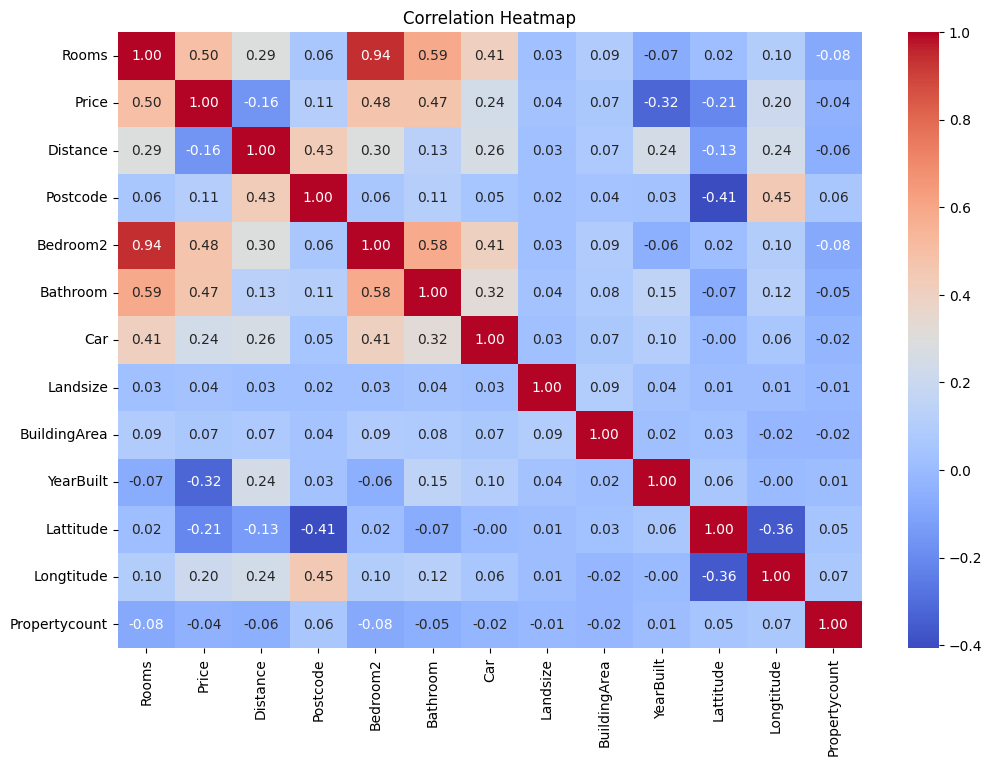

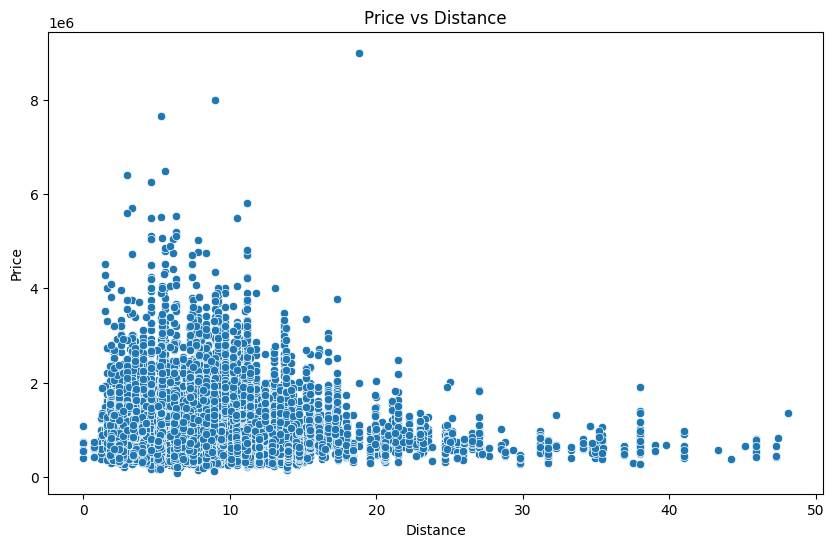

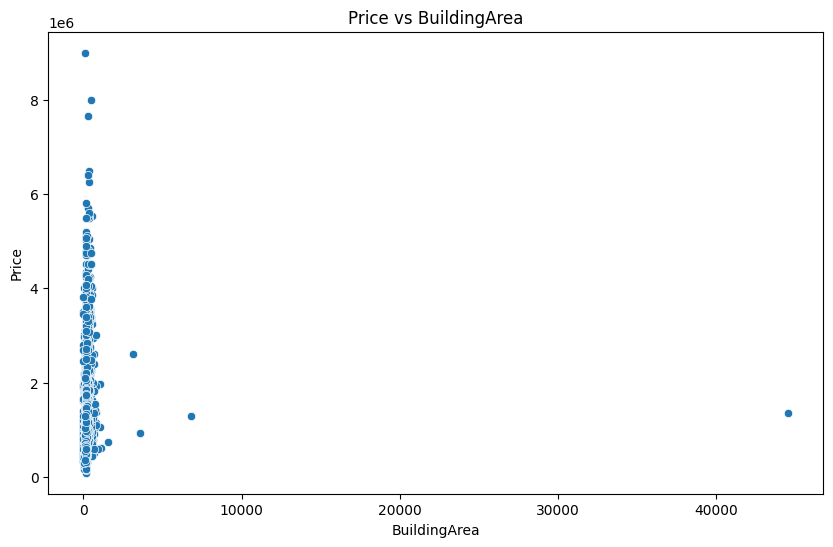

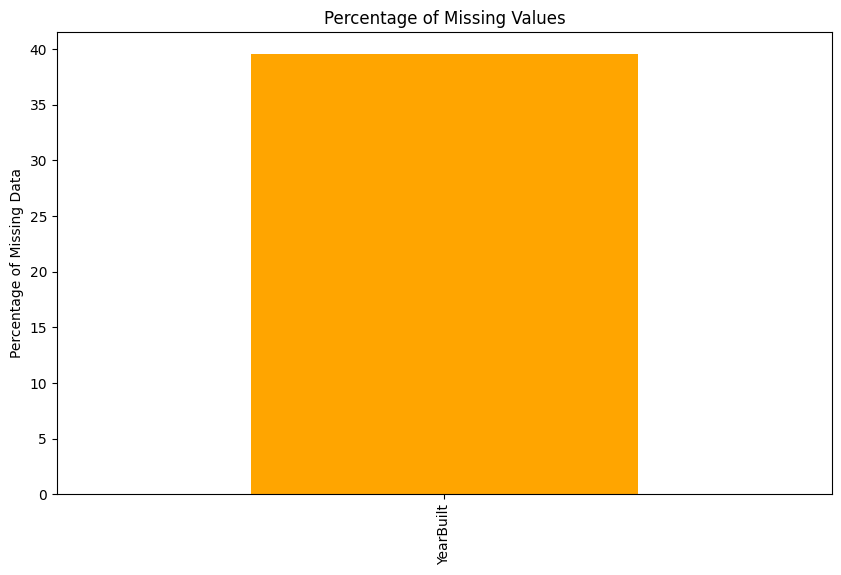

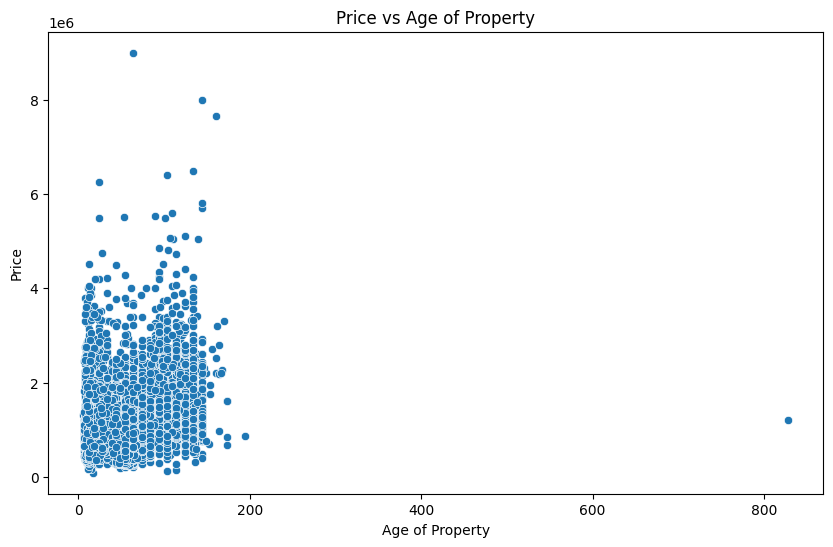

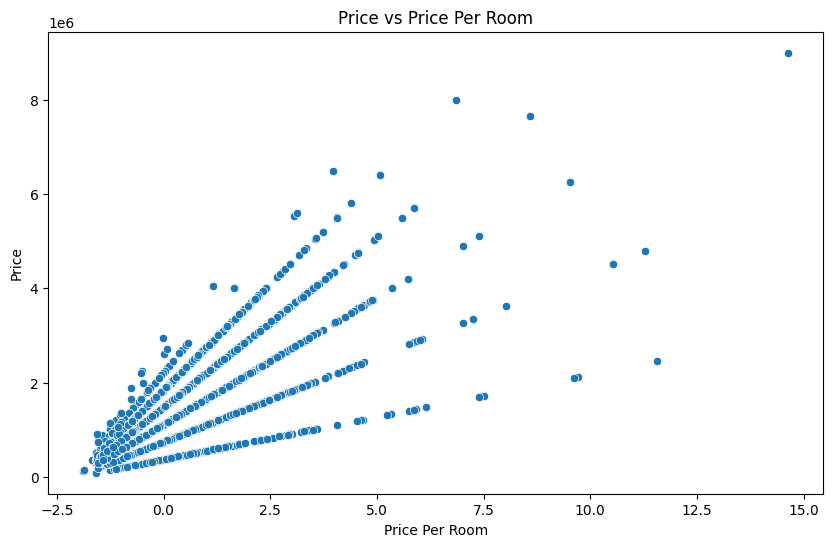

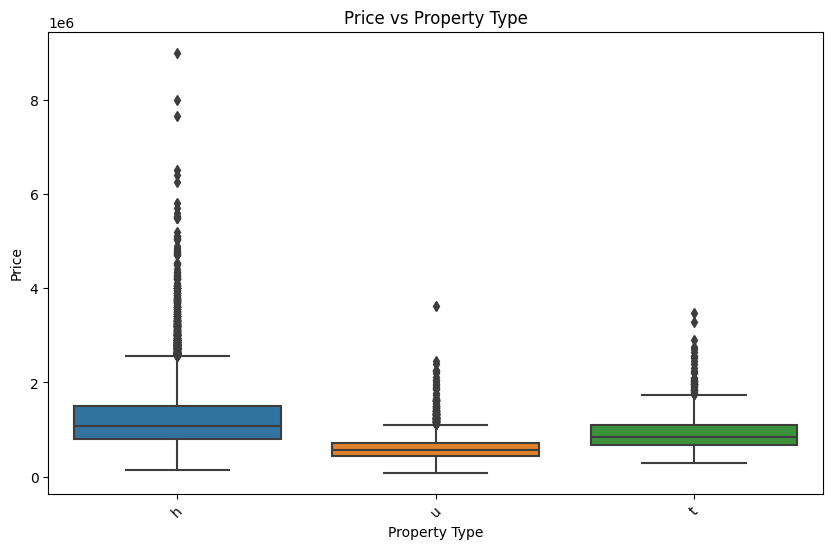

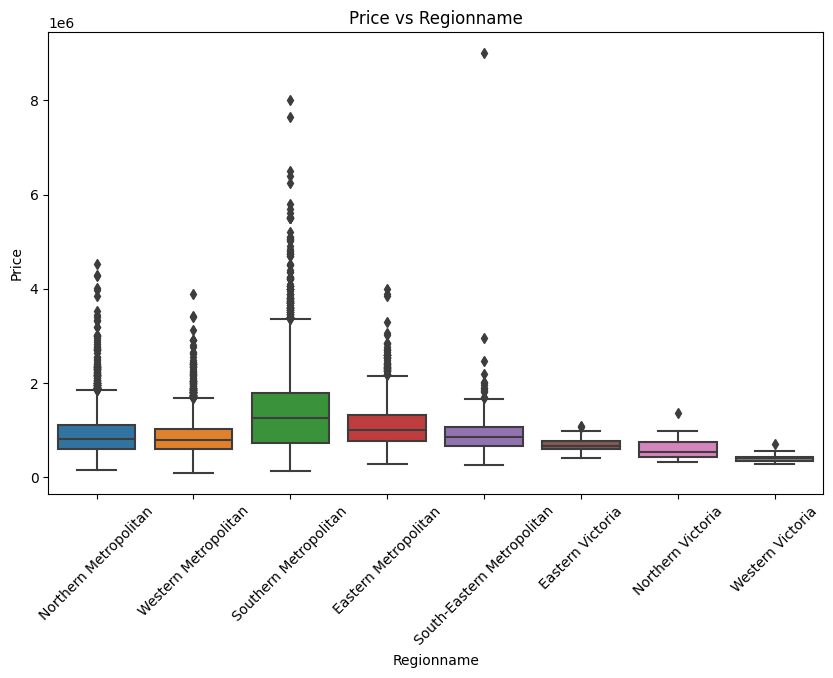

In [4]:
# Methodology to Achieve Objectives
# The main objective is to explore relationships between features and identify patterns that could help predict house prices.

# Step 1: Exploratory Data Analysis (EDA)
# The first step is to perform EDA to understand how different features correlate with each other and with the target variable 'Price'.
# This involves the following:
# 1. Correlation Analysis: We will use a heatmap to analyze the correlation between numerical features and the target variable 'Price'.
#    This helps identify features that have strong relationships with the target variable and each other.
#    We will also use scatter plots to visualize these relationships in more detail.
# 2. Categorical Feature Analysis: We'll visualize the relationship between categorical features like 'Type' and 'Regionname' and the target variable 'Price' using box plots.

# Step 2: Feature Engineering
# Feature engineering is done to create new features that may improve the prediction power of the model.
# 1. Creating New Features:
#    - 'Age' of the property: We will calculate the age of the property by subtracting 'YearBuilt' from the current year (2024).
#      This can give us insights on how property age influences price.
#    - 'PricePerRoom': This is created by dividing 'Price' by 'Rooms' to understand the price dynamics per room.
# 2. Handling Missing Data:
#    - We'll handle missing data for numerical columns like 'BuildingArea' by using mean imputation.
#    - For categorical columns like 'CouncilArea', we'll use mode imputation.
#    - We'll visualize missing data to track the effectiveness of our imputation strategies.

# Step 3: Scaling Features
# Feature scaling is applied to numerical features like 'BuildingArea', 'Distance', and 'PricePerRoom'.
# Scaling ensures that all numerical features contribute equally when we move to modeling.

# Perform the necessary steps to explore the relationships

# 1. Correlation Analysis: Analyze the relationships between numerical variables
# Select only numerical columns for correlation analysis
numerical_data = data_final.select_dtypes(include=[np.number])

# Correlation heatmap to explore the relationships between numerical features and target variable 'Price'
plt.figure(figsize=(12, 8))
correlation_matrix = numerical_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

# Scatter plot for Price vs Distance to understand the relationship between these two features
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data_final['Distance'], y=data_final['Price'])
plt.title('Price vs Distance')
plt.xlabel('Distance')
plt.ylabel('Price')
plt.show()

# Scatter plot for Price vs BuildingArea to understand the relationship between these two features
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data_final['BuildingArea'], y=data_final['Price'])
plt.title('Price vs BuildingArea')
plt.xlabel('BuildingArea')
plt.ylabel('Price')
plt.show()

# 2. Handling Missing Data: Investigate and address missing values
# Calculate and visualize missing data percentages
missing_data = data_final.isnull().sum() / len(data_final) * 100
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

# Plot the missing data percentages for each feature
missing_data.plot(kind='bar', figsize=(10, 6), color='orange')
plt.title('Percentage of Missing Values')
plt.ylabel('Percentage of Missing Data')
plt.show()

# Handling missing values: Drop rows or use imputation based on feature type
data_final['BuildingArea'].fillna(data_final['BuildingArea'].mean(), inplace=True)

# Example: Imputing missing values for categorical columns ( 'CouncilArea' with mode)
data_final['CouncilArea'].fillna(data_final['CouncilArea'].mode()[0], inplace=True)

# 3. Feature Engineering: Create new features to enhance predictions
# Create 'Age' feature: Age of the property = Current Year - YearBuilt
if 'YearBuilt' in data_final.columns:
    data_final['Age'] = 2024 - data_final['YearBuilt']
else:
    print("YearBuilt column is missing")

# Create 'PricePerRoom' feature: Price per room = Price / Number of Rooms
data_final['PricePerRoom'] = data_final['Price'] / data_final['Rooms']

# 4. Feature Scaling: Standardize numerical features for modeling
# Standardizing numerical features ( 'BuildingArea', 'Distance', 'PricePerRoom') using StandardScaler
scaler = StandardScaler()
data_final[['BuildingArea', 'Distance', 'PricePerRoom']] = scaler.fit_transform(
    data_final[['BuildingArea', 'Distance', 'PricePerRoom']]
)

# 5. Visualizing New Features: Check the relationship between newly created features and target variable 'Price'
# Scatter plot for Age of Property vs Price to explore their relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data_final['Age'], y=data_final['Price'])
plt.title('Price vs Age of Property')
plt.xlabel('Age of Property')
plt.ylabel('Price')
plt.show()

# Scatter plot for Price Per Room vs Price to explore their relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data_final['PricePerRoom'], y=data_final['Price'])
plt.title('Price vs Price Per Room')
plt.xlabel('Price Per Room')
plt.ylabel('Price')
plt.show()

# 6. Categorical Feature Analysis: Investigate the impact of categorical features on the target variable
# Boxplot for Property Type vs Price to visualize the relationship
plt.figure(figsize=(10, 6))
sns.boxplot(x=data_final['Type'], y=data_final['Price'])
plt.title('Price vs Property Type')
plt.xlabel('Property Type')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.show()

# Boxplot for Regionname vs Price to visualize the relationship
plt.figure(figsize=(10, 6))
sns.boxplot(x=data_final['Regionname'], y=data_final['Price'])
plt.title('Price vs Regionname')
plt.xlabel('Regionname')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.show()

# 7. Conclusion and Next Steps:
# From the correlation analysis and scatter plots:
# - 'BuildingArea', 'Distance', and 'PricePerRoom' are significant predictors of 'Price'.
# - Categorical features like 'Type' and 'Regionname' show a notable impact on price (as seen in boxplots).
# - Imputation for missing values, particularly for 'BuildingArea' and 'CouncilArea', was successfully applied.
# - Feature engineering with 'Age' and 'PricePerRoom' provides valuable insights.

# Next Steps:
# - Further feature engineering could include interaction terms between features like 'BuildingArea' and 'Regionname'.
# - Explore more advanced imputation techniques or methods to handle missing data more effectively.
# - Experiment with machine learning models and evaluate performance using the new features.


# 4. Data modeling:
- Satisfied by your data ?
- Run simple clustering or regression.
- Evaluate your data modeling by choosing the right evaluatiors( clustering or regression).
- Make visualization. 

R² (Coefficient of Determination): 0.0302
Mean Absolute Error (MAE): 450339.0650
Mean Squared Error (MSE): 398777910246.7119


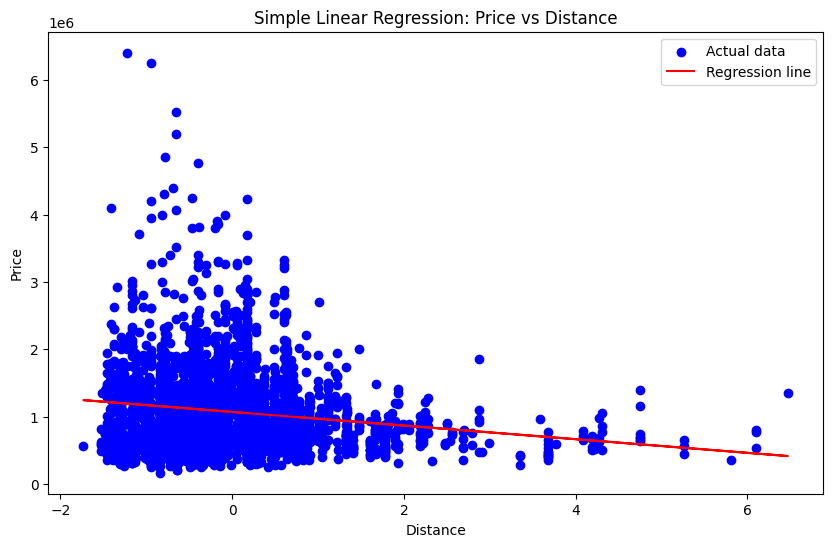

In [5]:
# Data modeling: Simple Linear Regression with 'Distance' as the predictor variable

# Select features and target
X = data_final[['Distance']]  # Predictor variable
y = data_final['Price']  # Target variable

# Split the data into training and test sets (80%-20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the linear regression model
reg_model = LinearRegression()

# Train the model
reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = reg_model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R² (Coefficient of Determination): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")

# Visualizing the regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual data')
plt.plot(X_test, y_pred, color='red', label='Regression line')
plt.title('Simple Linear Regression: Price vs Distance')
plt.xlabel('Distance')
plt.ylabel('Price')
plt.legend()
plt.show()

# 5. Communicate results: 
- Provide textual description of your work.
- Use visualizations to simplify your findings, and communicate it.
- Any decisions based on facts ?


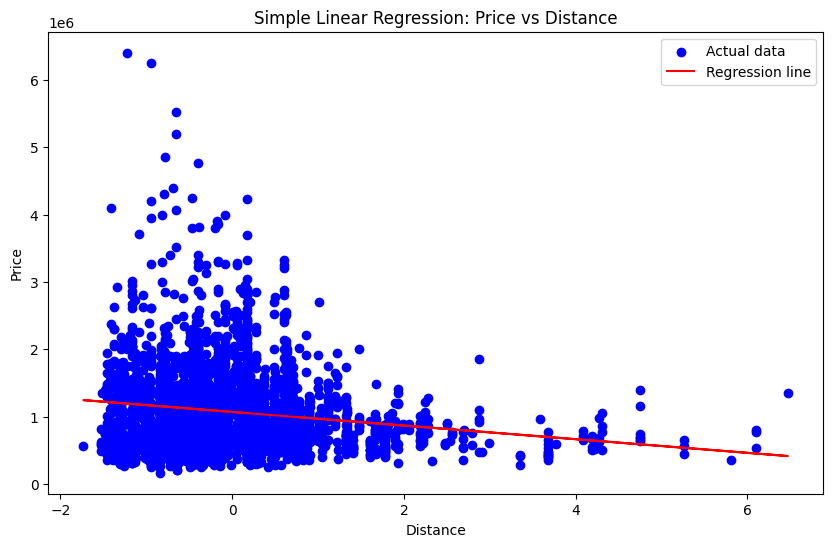

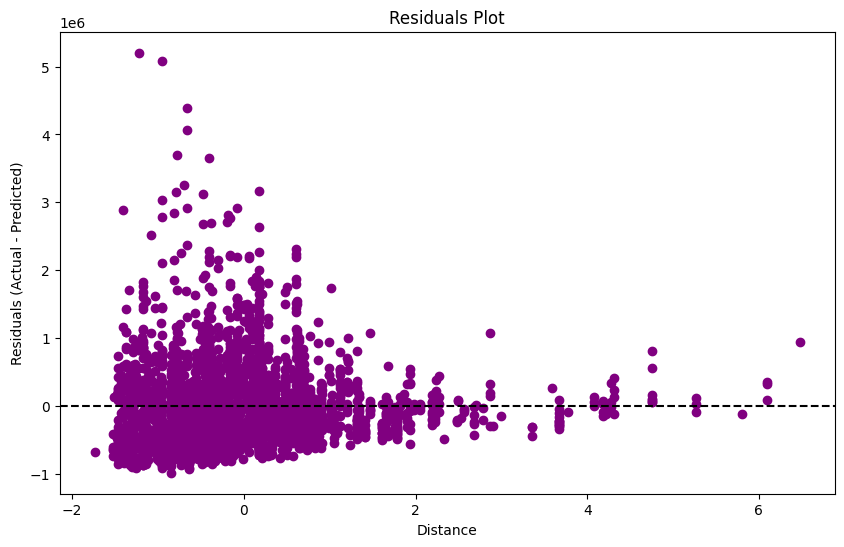

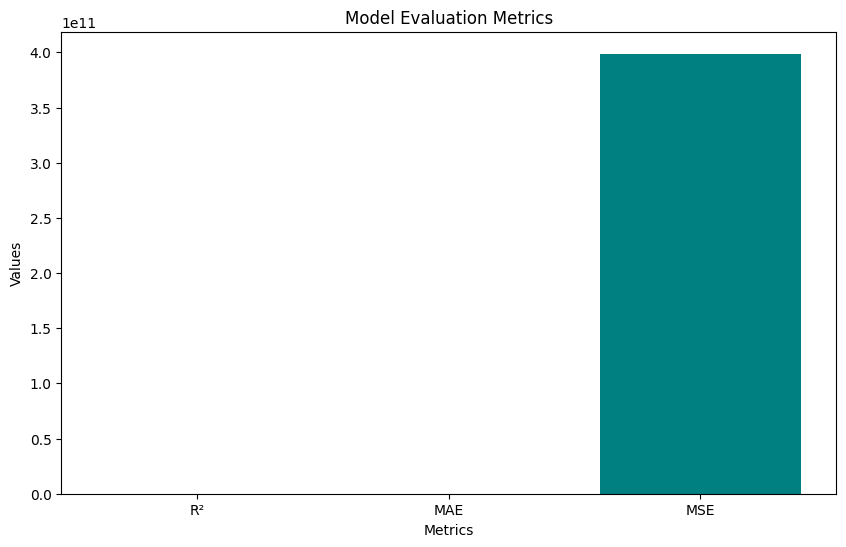

In [6]:

# Assuming y_test, y_pred, X_test, and data_final are already defined from previous steps

# --- Textual Description (as comments) ---
# In this analysis, we performed a simple linear regression to predict the Price of properties based on the Distance feature.
# We first evaluated the quality of the data, handled missing values, and ensured that the data was suitable for modeling.
# The linear regression model was trained using 80% of the data and tested on 20%. The model's performance was evaluated using metrics like R²,
# Mean Absolute Error (MAE), and Mean Squared Error (MSE).

# --- Visualization of Regression Line ---
# 1. Scatter Plot with Regression Line
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual data')  # Actual data points
plt.plot(X_test, y_pred, color='red', label='Regression line')  # Regression line
plt.title('Simple Linear Regression: Price vs Distance')
plt.xlabel('Distance')
plt.ylabel('Price')
plt.legend()
plt.show()

# --- Residuals Plot ---
# 2. Residuals Plot
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(X_test, residuals, color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residuals Plot')
plt.xlabel('Distance')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()



# --- Model Evaluation Metrics ---
# 4. Model Evaluation Metrics (R², MAE, MSE)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Visualization of model evaluation metrics
metrics = {'R²': r2, 'MAE': mae, 'MSE': mse}
metrics_names = list(metrics.keys())
metrics_values = list(metrics.values())

plt.figure(figsize=(10, 6))
plt.bar(metrics_names, metrics_values, color='teal')
plt.title("Model Evaluation Metrics")
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.show()

# --- Key Findings ---
# - The R² value indicates how much of the variance in Price is explained by Distance.
# - A higher R² value suggests a better fit.
# - The MAE and MSE provide an understanding of how far off the predictions are on average.

# --- Decisions Based on Facts ---
# If the R² is low, we might decide to add more features (e.g., BuildingArea, Rooms) to improve the model.
# If the model is not performing well, we may consider advanced modeling techniques like multiple linear regression or non-linear models.
# These steps and findings provide insight into the relationship between Distance and Price, guiding further improvements in the predictive model.
